# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **BreastMNIST**, un conjunto de ecografías mamarias en escala de grises con dos clases.

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar BreastMNIST

Imágenes de ecografía mamaria en escala de grises. La tarea es **clasificación binaria** entre las dos etiquetas definidas por MedMNIST. Usamos imágenes redimensionadas a 64 × 64 píxeles. Estos modelos de clase son ejercicios académicos, no diagnósticos.


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [ ]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", size=64, transform=transform_basic, download=True)
val_dataset = DataClass(split="val", size=64, transform=transform_basic, download=True)
test_dataset = DataClass(split="test", size=64, transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 2.85M/2.85M [00:04<00:00, 659kB/s]


(546, 78, 156)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


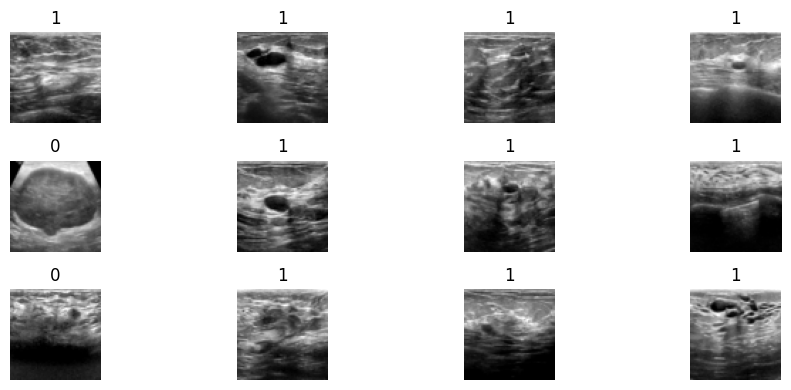

In [ ]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 64, 64]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        all_labels.append(y.numpy().reshape(-1))
        all_probs.append(logits_to_probs(logits).cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = y_prob.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob[:, 1])
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().reshape(-1)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 40
history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model_scratch, train_loader, optimizer, criterion
    )

    model_scratch.eval()
    total_val_loss = 0
    total_images = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device).long().reshape(-1)

            loss = criterion(model_scratch(x), y)
            total_val_loss += loss.item() * len(y)
            total_images += len(y)

    val_loss = total_val_loss / total_images
    train_acc, _, _, _, _ = evaluate(model_scratch, train_loader)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )


Epoch 01 | train_loss=0.4840 | val_loss=0.4477 | train_acc=0.7692 | val_acc=0.7564 | val_auc=0.8622
Epoch 02 | train_loss=0.4755 | val_loss=0.4378 | train_acc=0.8132 | val_acc=0.8205 | val_auc=0.8605
Epoch 03 | train_loss=0.4745 | val_loss=0.4199 | train_acc=0.7875 | val_acc=0.7692 | val_auc=0.8596
Epoch 04 | train_loss=0.4626 | val_loss=0.4339 | train_acc=0.8223 | val_acc=0.8205 | val_auc=0.8580
Epoch 05 | train_loss=0.4692 | val_loss=0.4133 | train_acc=0.8114 | val_acc=0.7564 | val_auc=0.8613
Epoch 06 | train_loss=0.4650 | val_loss=0.4144 | train_acc=0.7967 | val_acc=0.7692 | val_auc=0.8588
Epoch 07 | train_loss=0.4660 | val_loss=0.4329 | train_acc=0.8242 | val_acc=0.8333 | val_auc=0.8588
Epoch 08 | train_loss=0.4758 | val_loss=0.4109 | train_acc=0.8022 | val_acc=0.7821 | val_auc=0.8622
Epoch 09 | train_loss=0.4566 | val_loss=0.4127 | train_acc=0.8223 | val_acc=0.8205 | val_auc=0.8622
Epoch 10 | train_loss=0.4632 | val_loss=0.4112 | train_acc=0.8297 | val_acc=0.8205 | val_auc=0.8638


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


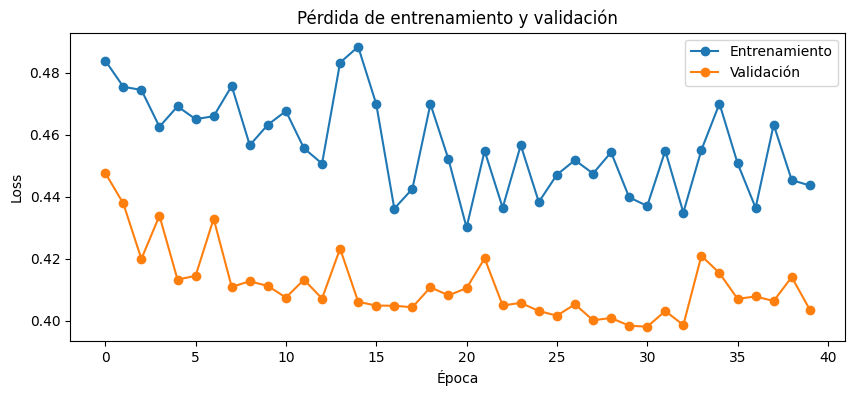

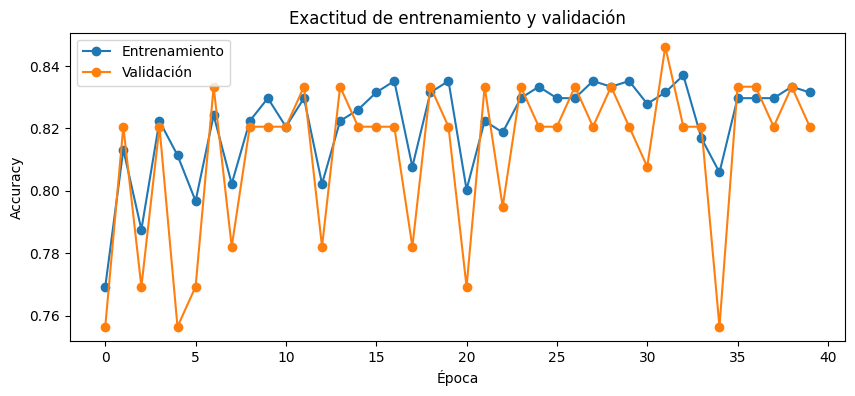

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"],
         color="tab:blue", marker="o", label="Entrenamiento")
plt.plot(history_scratch["val_loss"],
         color="tab:orange", marker="o", label="Validación")
plt.title("Pérdida de entrenamiento y validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_acc"],
         color="tab:blue", marker="o", label="Entrenamiento")
plt.plot(history_scratch["val_acc"],
         color="tab:orange", marker="o", label="Validación")
plt.title("Exactitud de entrenamiento y validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [ ]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.7308
Test ROC-AUC:  0.7636

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        42
           1     0.7308    1.0000    0.8444       114

    accuracy                         0.7308       156
   macro avg     0.3654    0.5000    0.4222       156
weighted avg     0.5340    0.7308    0.6171       156



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[  0,  42],
       [  0, 114]])

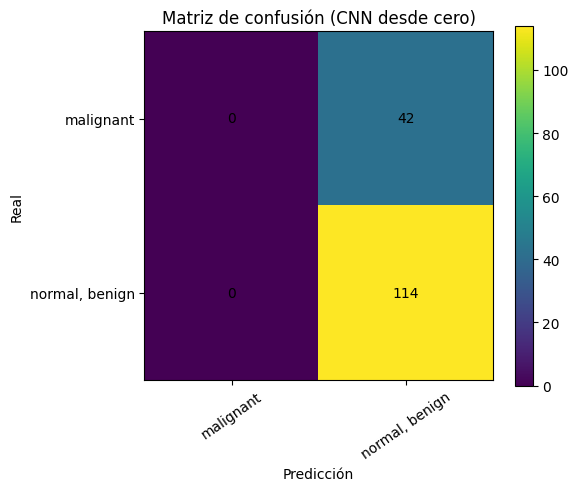

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(range(num_classes), [info["label"][str(i)] for i in range(num_classes)], rotation=35)
plt.yticks(range(num_classes), [info["label"][str(i)] for i in range(num_classes)])
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [ ]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", size=64, transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [ ]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.6271 | val_acc=0.7308 | val_auc=0.5698
Epoch 02 | train_loss=0.5758 | val_acc=0.7308 | val_auc=0.5647
Epoch 03 | train_loss=0.5894 | val_acc=0.7308 | val_auc=0.5698
Epoch 04 | train_loss=0.5770 | val_acc=0.7308 | val_auc=0.5698
Epoch 05 | train_loss=0.5868 | val_acc=0.7308 | val_auc=0.5698
Epoch 06 | train_loss=0.5634 | val_acc=0.7308 | val_auc=0.5656


### 6.1. Comparación rápida


In [ ]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.7308 | test_auc=0.7636
Con augmentation  | test_acc=0.7308 | test_auc=0.5986


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [ ]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", size=64, transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", size=64, transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", size=64, transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.6411 | val_acc=0.7179 | val_auc=0.5472
Stage1 Epoch 02 | train_loss=0.5925 | val_acc=0.6923 | val_auc=0.5539
Stage1 Epoch 03 | train_loss=0.5475 | val_acc=0.7179 | val_auc=0.5764
Stage1 Epoch 04 | train_loss=0.5235 | val_acc=0.7436 | val_auc=0.6600


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [ ]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [ ]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.4581 | val_acc=0.7692 | val_auc=0.8755
Stage2 Epoch 02 | train_loss=0.3495 | val_acc=0.8333 | val_auc=0.9231
Stage2 Epoch 03 | train_loss=0.2966 | val_acc=0.8590 | val_auc=0.9432
Stage2 Epoch 04 | train_loss=0.2195 | val_acc=0.9103 | val_auc=0.9357


### 7.3. Evaluación en test del modelo con transfer learning


In [ ]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8462 | test_auc=0.9066

              precision    recall  f1-score   support

           0     0.8750    0.5000    0.6364        42
           1     0.8409    0.9737    0.9024       114

    accuracy                         0.8462       156
   macro avg     0.8580    0.7368    0.7694       156
weighted avg     0.8501    0.8462    0.8308       156



array([[ 21,  21],
       [  3, 111]])

### 7.4. Comparación global (resumen)


In [ ]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.7308 | auc=0.7636
CNN desde cero (con aug)  | acc=0.7308 | auc=0.5986
Transfer learning (ResNet) | acc=0.8462 | auc=0.9066


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [ ]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


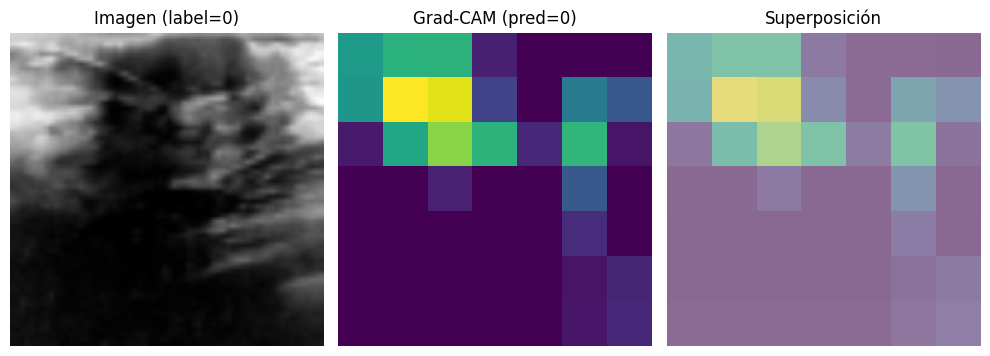

In [ ]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Mi actividad
Mi conjunto de datos contiene ecografías mamarias de dos clases. Primero adapté el número de salidas de la CNN y la forma de evaluar los resultados. Después probé cambios en la arquitectura, la tasa de aprendizaje, el aumento de datos y la calibración de probabilidades.

Separé los datos en entrenamiento, validación y prueba. Usé validación para comparar los experimentos y reservé prueba para el resultado final. Las salidas que aparecen más abajo se calculan al ejecutar el notebook.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from medmnist import INFO
import medmnist
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, log_loss
from scipy.optimize import minimize_scalar

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Aquí cambié el dataset del ejemplo por las ecografías de mama.
flag_11 = "breastmnist"
info_11 = INFO[flag_11]
Dataset11 = getattr(medmnist, info_11["python_class"])
num_classes_11 = len(info_11["label"])
labels_11 = [info_11["label"][str(i)] for i in range(num_classes_11)]

# Uso el mismo tamaño de imagen en entrenamiento, validación y prueba.
size_11 = 64
batch_11 = 64
base_11 = T.ToTensor()
train_11 = Dataset11(split="train", size=size_11, transform=base_11, download=True)
val_11 = Dataset11(split="val", size=size_11, transform=base_11, download=True)
test_11 = Dataset11(split="test", size=size_11, transform=base_11, download=True)
def loader_11(ds, shuffle=False):
    return DataLoader(ds, batch_size=batch_11, shuffle=shuffle, num_workers=0)

# Se mezcla solo el entrenamiento, validación y prueba.
train_loader_11 = loader_11(train_11, True)
val_loader_11 = loader_11(val_11)
test_loader_11 = loader_11(test_11)
print("Dataset:", flag_11, "Clases:", labels_11)
print("Train / val / test:", len(train_11), len(val_11), len(test_11))


Dataset: breastmnist Clases: ['malignant', 'normal, benign']
Train / val / test: 546 78 156


### Cambio de la CNN

A la CNN le agregué *BatchNorm* para ayudar a estabilizar el entrenamiento, *Dropout* para reducir el riesgo de sobreajuste y más filtros para extraer características de las imágenes. La última capa tiene dos salidas porque BreastMNIST tiene dos clases.


In [ ]:
# Agregué más filtros, BatchNorm y Dropout a mi CNN.
class CNN11(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_classes))
    # Primero extraigo características y luego obtengo una puntuación por clase.
    def forward(self, x):
        return self.classifier(self.features(x))
@torch.no_grad()
def predict_11(model, data_loader, temperature=1.0):
    model.eval()
    yy, zz = [], []
    for x, y in data_loader:
        yy.append(y.numpy().reshape(-1))
        zz.append(model(x.to(device)).cpu().numpy())
    y = np.concatenate(yy)
    z = np.concatenate(zz)
    p = torch.softmax(torch.tensor(z / temperature), dim=1).numpy()
    return y, z, p

# Para el AUC binario tomo la probabilidad de la clase 1.
def scores_11(y, p):
    acc = accuracy_score(y, p.argmax(axis=1))
    auc_binaria = roc_auc_score(y, p[:, 1])
    return acc, auc_binaria

# Esta función entrena la CNN y registra las métricas de cada época.
def fit_11(train_loader, lr=1e-3, epochs=3, scheduler=False):
    torch.manual_seed(42)
    model = CNN11(num_classes_11).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # El scheduler baja la tasa de aprendizaje después de dos épocas.
    schedule = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5) if scheduler else None
    history = []
    for epoch in range(epochs):
        model.train()
        total, count = 0., 0
        for x, y in train_loader:
            x = x.to(device)
            y = y.reshape(-1).long().to(device)
            optimizer.zero_grad()
            loss = nn.functional.cross_entropy(model(x), y)
            loss.backward()
            optimizer.step()
            total += loss.item() * len(y)
            count += len(y)
        if schedule is not None:
            schedule.step()
        # Evalúo entrenamiento y validación para poder dibujar ambas curvas.
        yt, _, pt = predict_11(model, loader_11(train_11))
        yv, _, pv = predict_11(model, val_loader_11)
        train_acc = accuracy_score(yt, pt.argmax(axis=1))
        val_acc, auc_binaria = scores_11(yv, pv)
        val_loss = log_loss(yv, pv, labels=np.arange(num_classes_11))
        history.append((total / count, val_acc, auc_binaria, val_loss, train_acc))
        print(f"Época {epoch+1}: train_loss={total/count:.4f} val_loss={val_loss:.4f} "
              f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} val_AUC={auc_binaria:.4f}")
    return model, history

# Comparo dos tasas de aprendizaje con la misma arquitectura.
model_lr1_11, hist_lr1_11 = fit_11(train_loader_11, lr=1e-3, epochs=3, scheduler=False)
model_lr2_11, hist_lr2_11 = fit_11(train_loader_11, lr=3e-4, epochs=3, scheduler=True)
print("Comparación (validación):", {"Adam 1e-3": hist_lr1_11[-1], "Adam 3e-4 + StepLR": hist_lr2_11[-1]})


Época 1: train_loss=0.5297 val_loss=0.7689 train_acc=0.2692 val_acc=0.2692 val_AUC=0.6065
Época 2: train_loss=0.4737 val_loss=1.1004 train_acc=0.2692 val_acc=0.2692 val_AUC=0.5497
Época 3: train_loss=0.4588 val_loss=1.2632 train_acc=0.2692 val_acc=0.2692 val_AUC=0.5497
Época 1: train_loss=0.5733 val_loss=0.7236 train_acc=0.2692 val_acc=0.2692 val_AUC=0.6675
Época 2: train_loss=0.4989 val_loss=0.9709 train_acc=0.2692 val_acc=0.2692 val_AUC=0.6399
Época 3: train_loss=0.4811 val_loss=1.2319 train_acc=0.2692 val_acc=0.2692 val_AUC=0.6926
Comparación (validación): {'Adam 1e-3': (0.4588113262321486, 0.2692307692307692, np.float64(0.5497076023391813), 1.2631546964007847, 0.2692307692307692), 'Adam 3e-4 + StepLR': (0.4811193869882451, 0.2692307692307692, np.float64(0.692564745196324), 1.2319195741989357, 0.2692307692307692)}


### Curvas de entrenamiento y validación

Aquí grafiqué la **pérdida** y la **exactitud** de entrenamiento y validación para cada configuración. La pérdida indica cuánto se equivoca el modelo durante el cálculo; la exactitud muestra qué proporción de imágenes clasificó correctamente.

Al revisar las curvas, me fijo en si ambas pérdidas bajan y en la distancia entre entrenamiento y validación. Una separación grande, con entrenamiento mejorando mientras validación empeora, sería señal de posible sobreajuste. Los valores concretos aparecerán al ejecutar las celdas.


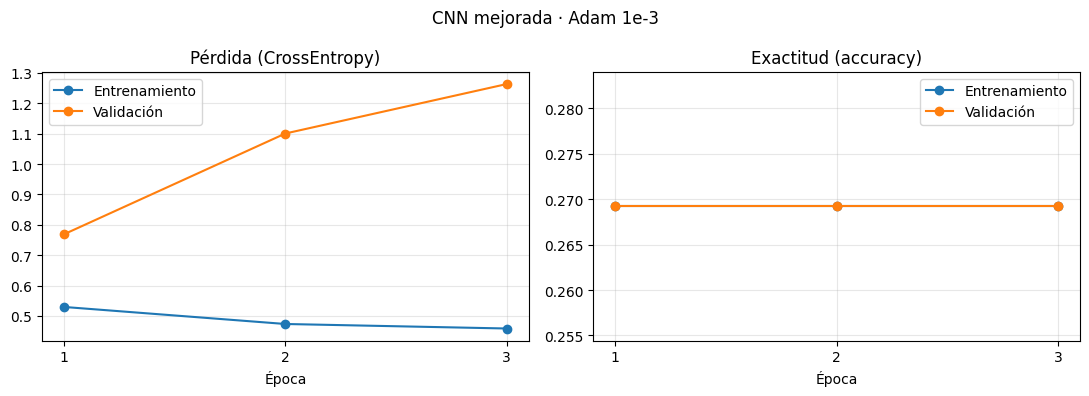

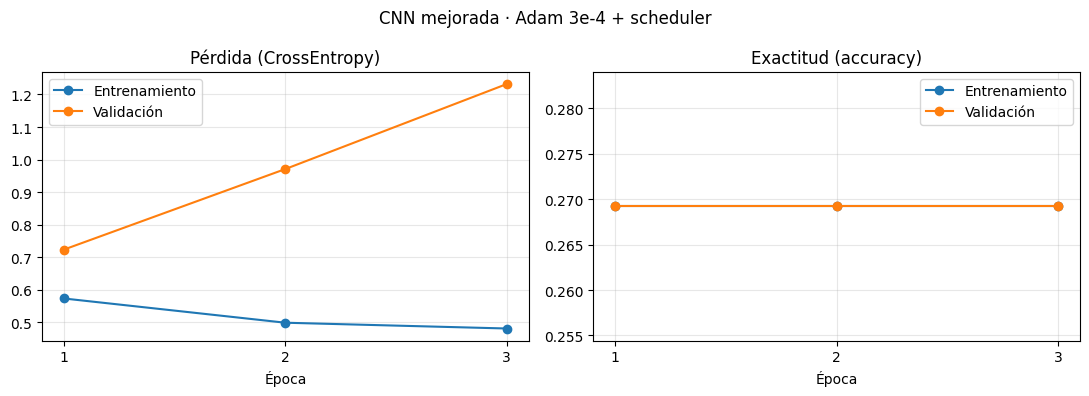

In [ ]:
# Grafico pérdida y exactitud para detectar mejoras o posible sobreajuste.
def plot_curves_11(history, title):
    epochs = np.arange(1, len(history) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# A la izquierda comparo cómo baja la pérdida en ambos conjuntos.
    axes[0].plot(epochs, [v[0] for v in history], marker="o", label="Entrenamiento")
    axes[0].plot(epochs, [v[3] for v in history], marker="o", label="Validación")
    axes[0].set_title("Pérdida (CrossEntropy)")
# A la derecha comparo la proporción de aciertos por época.
    axes[1].plot(epochs, [v[4] for v in history], marker="o", label="Entrenamiento")
    axes[1].plot(epochs, [v[1] for v in history], marker="o", label="Validación")
    axes[1].set_title("Exactitud (accuracy)")
    for ax in axes:
        ax.set_xlabel("Época")
        ax.set_xticks(epochs)
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_curves_11(hist_lr1_11, "CNN mejorada · Adam 1e-3")
plot_curves_11(hist_lr2_11, "CNN mejorada · Adam 3e-4 + scheduler")



###Aumento de datos

Hice otro entrenamiento con pequeñas *rotaciones y traslaciones* aplicadas solo a las imágenes de entrenamiento. La idea es que la CNN vea variaciones de una misma imagen y aprenda patrones menos dependientes de su posición exacta. Luego, se compara este experimento con la CNN sin aumento usando las curvas y el AUC de *validación*.


Época 1: train_loss=0.5578 val_loss=0.7535 train_acc=0.2692 val_acc=0.2692 val_AUC=0.6074
Época 2: train_loss=0.5177 val_loss=1.1391 train_acc=0.2692 val_acc=0.2692 val_AUC=0.6541
Época 3: train_loss=0.4944 val_loss=1.2586 train_acc=0.2711 val_acc=0.2692 val_AUC=0.5589
Sin aumento: (0.4588113262321486, 0.2692307692307692, np.float64(0.5497076023391813), 1.2631546964007847, 0.2692307692307692)
Con aumento: (0.4944465092686943, 0.2692307692307692, np.float64(0.5588972431077694), 1.2585601928080312, 0.27106227106227104)


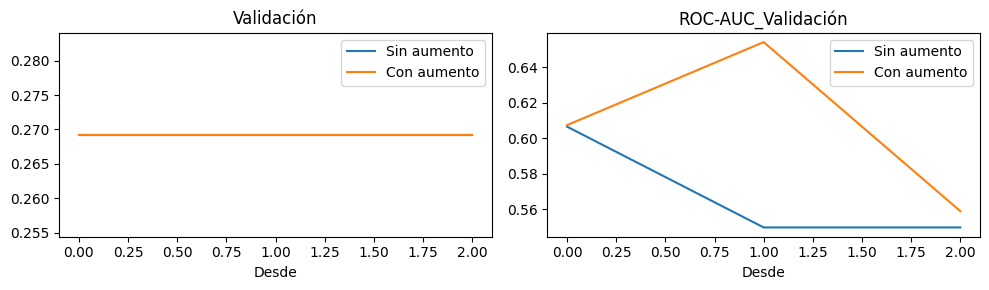

In [ ]:
# Aplico pequeñas variaciones únicamente a las imágenes de entrenamiento.
aug_11 = T.Compose([
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])
train_aug_11 = Dataset11(split="train", size=size_11, transform=aug_11, download=True)
model_aug_11, hist_aug_11 = fit_11(loader_11(train_aug_11, True), lr=1e-3, epochs=3)
print("Sin aumento:", hist_lr1_11[-1])
print("Con aumento:", hist_aug_11[-1])

# Estas gráficas comparan los resultados de validación con y sin aumento.
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
for h, label in [(hist_lr1_11, "Sin aumento"), (hist_aug_11, "Con aumento")]:
    ax[0].plot([v[1] for v in h], label=label)
    ax[1].plot([v[2] for v in h], label=label)
ax[0].set_title("Validación")
ax[1].set_title("ROC-AUC_Validación")
for a in ax:
    a.set_xlabel("Desde")
    a.legend()
plt.tight_layout()
plt.show()


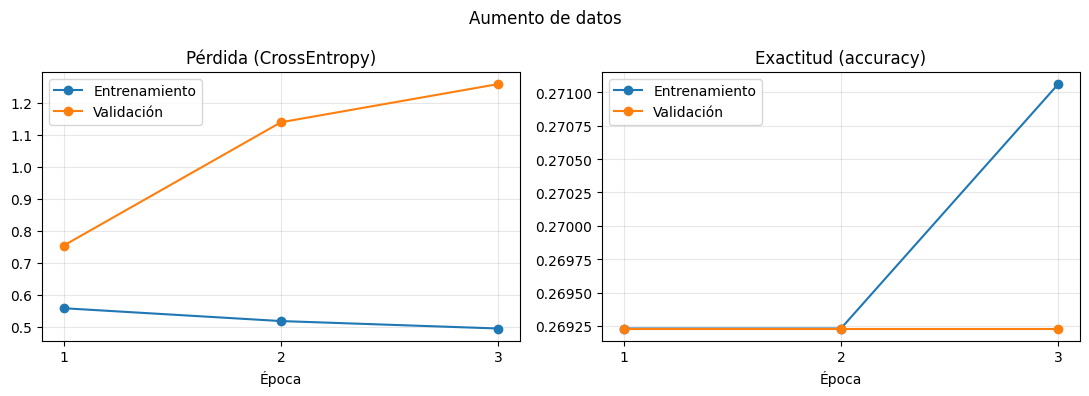

In [ ]:
plot_curves_11(hist_aug_11, "Aumento de datos")


###Calibración de probabilidades y trazo la curva ROC

Primero selecciono el modelo que obtuvo el mayor AUC en *validación*. Luego ajusto una *temperatura* con ese mismo conjunto para calibrar las probabilidades.En la curva ROC se observo cómo cambia la sensibilidad frente a la tasa de falsos positivos para distintos umbrales, luego se compara las curvas antes y después de calibrar. La calibración por temperatura puede cambiar el *log loss* sin cambiar el AUC, ya que no altera el orden de las predicciones.


Modelo: Adam Scheduler Temperatura: 20.0
Original: test_acc=0.2692, test_AUC=0.6984, test_log_loss=1.2314
Calibrado: test_acc=0.2692, test_AUC=0.6984, test_log_loss=0.7092


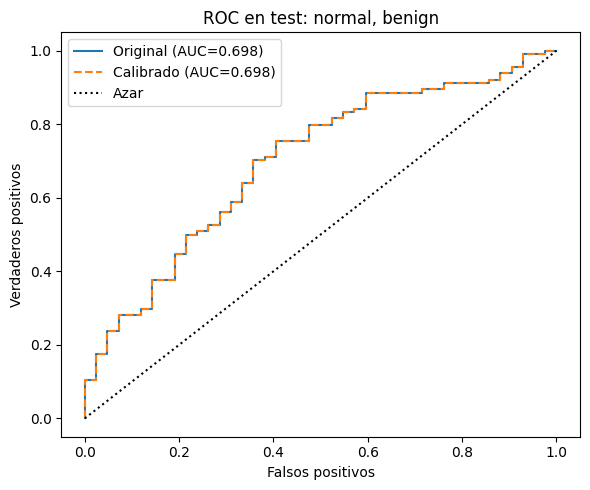

In [ ]:
# Elijo el mejor modelo usando AUC de validación, antes de mirar prueba.
candidatos_11 = [
    ("Adam 1e-3", model_lr1_11, hist_lr1_11[-1][2]),
    ("Adam Scheduler", model_lr2_11, hist_lr2_11[-1][2]),
    ("Aumento", model_aug_11, hist_aug_11[-1][2]),
]
name_11, best_11, _ = max(candidatos_11, key=lambda row: row[2])
y_val_11, z_val_11, _ = predict_11(best_11, val_loader_11)

# Busco una temperatura que reduzca el error de las probabilidades en validación.
def nll_temperature_11(log_t):
    t = np.exp(log_t)
    p = torch.softmax(torch.tensor(z_val_11 / t), dim=1).numpy()
    return log_loss(y_val_11, p, labels=np.arange(num_classes_11))

# Ajusto la calibración solo con validación.
result_11 = minimize_scalar(nll_temperature_11, bounds=(np.log(0.05), np.log(20)), method="bounded")
temp_11 = float(np.exp(result_11.x))
# Ahora sí evalúo las probabilidades originales y calibradas en prueba.
y_test_11, z_test_11, p_raw_11 = predict_11(best_11, test_loader_11)
p_cal_11 = torch.softmax(torch.tensor(z_test_11 / temp_11), dim=1).numpy()
print("Modelo:", name_11, "Temperatura:", round(temp_11, 3))
for name, p in [("Original", p_raw_11), ("Calibrado", p_cal_11)]:
    acc, auc_binaria = scores_11(y_test_11, p)
    print(f"{name}: test_acc={acc:.4f}, test_AUC={auc_binaria:.4f}, test_log_loss={log_loss(y_test_11, p, labels=np.arange(num_classes_11)):.4f}")

# Dibujo las curvas ROC usando la clase 1 como positiva.
fpr_raw_11, tpr_raw_11, _ = roc_curve(y_test_11, p_raw_11[:, 1])
fpr_cal_11, tpr_cal_11, _ = roc_curve(y_test_11, p_cal_11[:, 1])
plt.figure(figsize=(6, 5))
plt.plot(fpr_raw_11, tpr_raw_11, label=f"Original (AUC={auc(fpr_raw_11, tpr_raw_11):.3f})")
plt.plot(fpr_cal_11, tpr_cal_11, linestyle="--", label=f"Calibrado (AUC={auc(fpr_cal_11, tpr_cal_11):.3f})")
plt.plot([0, 1], [0, 1], "k:", label="Azar")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title(f"ROC en test: {labels_11[1]}")
plt.legend()
plt.tight_layout()
plt.show()
